# Analise dos dados

## Imports

In [154]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Envs

In [155]:
DATA_PATH = "data"
DATASET_ORIGIN = "KAGGLE"
DATASET_NAME = "IMDB Movie Reviews"
DATASET_KAGGLE_ID = "yeanzc/telco-customer-churn-ibm-dataset"
DATASET_DESTINATION = f"{DATA_PATH}/imdb_movie_reviews"
DATASET_FILE = "Telco_customer_churn.xlsx"


## Download dos dados

In [156]:
kagglehub.dataset_download(DATASET_KAGGLE_ID, output_dir=DATASET_DESTINATION)

'data/imdb_movie_reviews'

## Carregando os dados

In [157]:
dataset_raw = pd.read_excel(f"{DATASET_DESTINATION}/{DATASET_FILE}")

## Info dos dados

In [158]:
dataset_raw.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [159]:
dataset_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

Resumo do que foi encontrado:
- Volume: 7043 instancias e 33 colunas
- Qualidade: Apenas a ultima coluna `Churn Reason` tem dados nulos
> insight: Esperado pois apenas quem deu chrun tem motivo para colocar o reason
- Tipos de dados: float64(3), int64(6), object(1), str(23)
> insight: O objeto e as strings precisaram de enconding 


In [160]:
dataset_raw.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [161]:
dataset_raw.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Confirmado que apenas a coluna `Churn Reason` possui valores nulos, em um total de 5174 instancias

In [162]:
dataset_raw.duplicated().sum()

np.int64(0)

Nenhum dado duplicado foi encontrado

### Distribuição da variavel algo

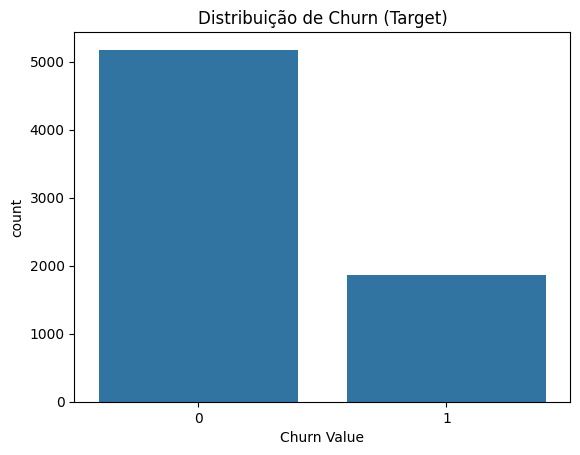

In [163]:
sns.countplot(x="Churn Value", data=dataset_raw)
plt.title("Distribuição de Churn (Target)")
plt.show()

A base se demonstra desbalanceada, o que indica que não é interessante utilizar Acurácia como métrica principal

### Tempo de contrato

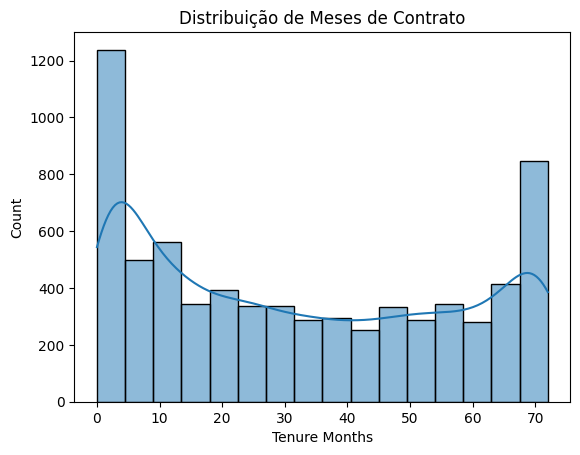

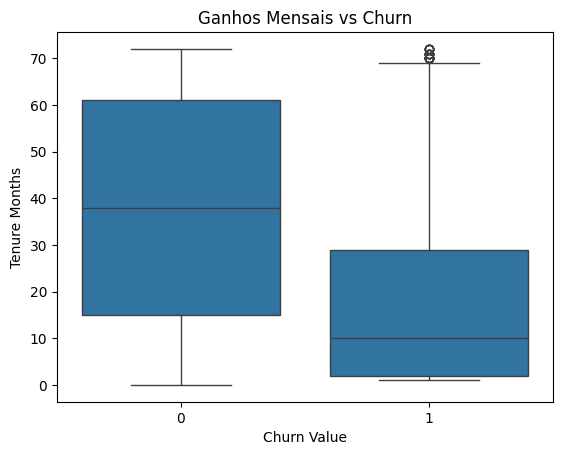

In [164]:
sns.histplot(data=dataset_raw, x="Tenure Months", kde=True)
plt.title("Distribuição de Meses de Contrato")
plt.show()

sns.boxplot(x="Churn Value", y="Tenure Months", data=dataset_raw)
plt.title("Ganhos Mensais vs Churn")
plt.show()


- Nossos clientes se concentram em grande maioria novos com 5 ou menos meses de contrato, enquanto o segundo publico mais relevantes tem 70 ou mais meses de contratos
- A análise bivariada (boxplot) confirma que 75% dos clientes que realizam churn o fazem antes dos 30 meses de contrato, indicando uma alta vulnerabilidade no primeiro ano de serviço
- Clientes com alto tempo de contrato (acima de 70 meses) que cancelam são considerados outliers. Para a primeira iteração do modelo (baseline), avaliaremos o impacto desses registros na performance, visando priorizar a predição do churn precoce

### Ganhos mensais

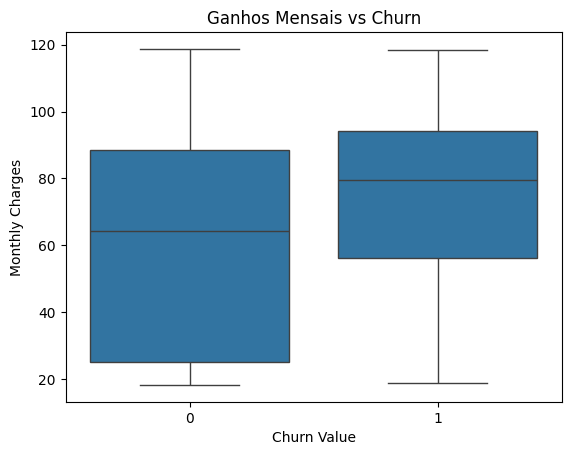

In [165]:
sns.boxplot(x="Churn Value", y="Monthly Charges", data=dataset_raw)
plt.title("Ganhos Mensais vs Churn")
plt.show()

- A mediana de gasto quem cancela é de cerca 80 unidades, enquanto de quem fica cerca de 65.
- Não existem outliers relevantes no gasto

### Total chages

In [166]:
dataset_raw["Total Charges"].head()

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
Name: Total Charges, dtype: object

- A coluna de ganhos total por cliente está como objeto, o que sugere a necessidade de tratamento desses dados antes de utilizar no modelo

### Tipo de contrato

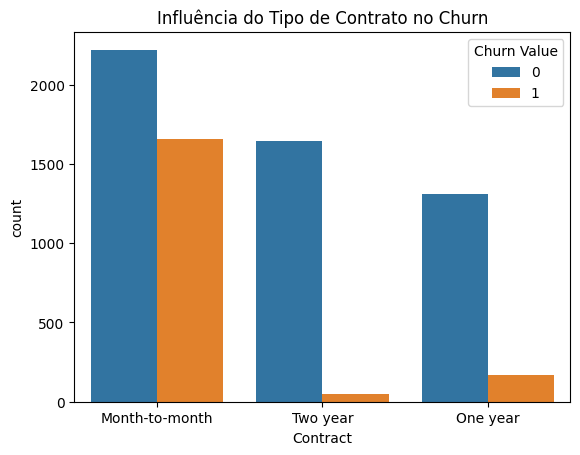

In [167]:
sns.countplot(x="Contract", hue="Churn Value", data=dataset_raw)
plt.title("Influência do Tipo de Contrato no Churn")
plt.show()

- Clientes com contratos mensais tendem a cancelar muito mais que os outros tipos de contrato, fazendo com que o tipo de contrato seja o principal preditor qualitativo para identificarmos o churn

### Outros dados

Com base nos dados base e entendimento do significado das colunas, dados geográficos não serão considerados pois todos os clientes se concentram na mesma região (California) e como não faremos um mapa de calor os mais especícios também não costuma ajudar uma rede neural

# Definição de métricas

## Técnicas

### Acurácia (não utilizar)
Dado o desbalanceamento das classes, o usuário da acurácia seria errado aqui, pois se 90% dos clientes ficarem e o modelo chutar que não existe churn, ele terá 90% de acurária.

### F1-Score (Utilizar)

Ela trará a média harmônica entre a Precisão e o Recall, fazendo com que não tenhamos alarmes falsos para clientes fiéis e não deixando passar quem terá churn

### PR-AUC (Utilizar)

Por focar sua performance na classe minoritária ele acaba sendo a melhor métrica para olharmos

### AUC-ROC (Utilizar - secundário)

Como ele faz o equilíbrio entre as taxas de acertos e alarmes falsos ele ajudará bastante nosso modelo, porém como ele pode acabar sendo otimista em relação aos dados devido a desproporção entre quem dá churn e quem não dá

## Negócios

### Custo de churn evitado

O custo do churn evitado pode ser calculado através da seguinte fórmula

`CE = (VP * LTV) - (VP * CR) - (FP * CR)`
> onde:<br>
> `CE` = Custo Evitado<br>
> `VP` = Verdadeiros Positivos<br>
> `LTV` = Lifetime Value (Valor total de retorno do cliente caso não tenha churn, irá vir do CLTV)<br>
> `CR` = Custo de Retenção (marketing e afins, vamos etipular 20% do ganho mensal do cliente)<br>
> `FP` = Falsos Positivos (isso influência no custo do marketing gasto com um cliente que não iria sair)

# Baseline

## Imports

In [168]:
from typing import Any, cast

import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## Envs

In [169]:
DATASET_TARGET_COLUMN = "Churn Value"
DATASET_TEST_SIZE = 0.2
DATASET_SPLIT_RANDOM_STATE = 42
LOG_REG_MAX_ITER = 1000
LOG_REG_RANDOM_STATE = 42

## Remoção de colunas irrelevantes

In [170]:
cols_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
]

dataset_ready = dataset_raw.drop(columns=cols_to_drop)

## Ajuste da coluna `Total Charges`

In [171]:
dataset_ready["Total Charges"] = pd.to_numeric(dataset_ready["Total Charges"], errors="coerce")
dataset_ready["Total Charges"] = dataset_ready["Total Charges"].fillna(
    dataset_ready["Total Charges"].median()
)

## Divisão do dataset

In [172]:
X = dataset_ready.drop(columns=[DATASET_TARGET_COLUMN])
y = dataset_ready[DATASET_TARGET_COLUMN]

print(f"Proporção de Churn no dataset original: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=DATASET_TEST_SIZE,
    random_state=DATASET_SPLIT_RANDOM_STATE,
    stratify=y,
)

print(f"Proporção de Churn no Treino: {y_train.mean():.2%}")
print(f"Proporção de Churn no Teste: {y_test.mean():.2%}")

Proporção de Churn no dataset original: 26.54%
Proporção de Churn no Treino: 26.54%
Proporção de Churn no Teste: 26.54%


## Tratamento dos dados

In [173]:
categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
]
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Treinando os baselines

### Função de avaliação

In [174]:
def evaluate_model(y_true, y_pred, y_probs) -> dict[str, float]:
    classification_rep_str = classification_report(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_probs)
    pr_auc = average_precision_score(y_true, y_probs)

    print(classification_rep_str)
    print(f"AUC-ROC: {auc_roc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")

    classification_rep = classification_report(y_true, y_pred, output_dict=True)
    classification_rep = cast(dict[str, Any], classification_rep)

    metrics = {
        "accuracy": classification_rep.get("accuracy", 0.0),
        "precision_weighted": classification_rep.get("weighted avg", {}).get("precision", 0.0),
        "recall_weighted": classification_rep.get("weighted avg", {}).get("recall", 0.0),
        "f1_weighted": classification_rep.get("weighted avg", {}).get("f1-score", 0.0),
        "auc_roc": auc_roc,
        "pr_auc": pr_auc,
    }
    return metrics

### Dummy

In [175]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_processed, y_train)

y_pred_dummy = dummy_clf.predict(X_test_processed)
y_probs_dummy = np.asarray(dummy_clf.predict_proba(X_test_processed))[:, 1]

metrics_dummy = evaluate_model(y_test, y_pred_dummy, y_probs_dummy)

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

AUC-ROC: 0.5000
PR-AUC: 0.2654


/Users/vand/Code/fiap/tech-challenge-fiap/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vand/Code/fiap/tech-challenge-fiap/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vand/Code/fiap/tech-challenge-fiap/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

### LogReg

In [176]:
log_reg = LogisticRegression(max_iter=LOG_REG_MAX_ITER, random_state=LOG_REG_RANDOM_STATE)
log_reg.fit(X_train_processed, y_train)

# Avaliando
y_pred_log = log_reg.predict(X_test_processed)
y_probs_log = np.asarray(log_reg.predict_proba(X_test_processed))[:, 1]

metrics_log = evaluate_model(y_test, y_pred_log, y_probs_log)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

AUC-ROC: 0.8489
PR-AUC: 0.6452


# Registrando experimentos no MLFow

## Imports

In [177]:
import os
import pickle
from pathlib import Path

import mlflow
import mlflow.sklearn as mlflow_sklearn
from dotenv import load_dotenv

## Envs

In [178]:
load_dotenv(dotenv_path="../.env")

MLFLOW_HOST = os.getenv("MLFLOW_HOST") or "http://localhost"
MLFLOW_PORT = os.getenv("MLFLOW_PORT") or "5500"
MLFLOW_TRACKING_URI = f"{MLFLOW_HOST}:{MLFLOW_PORT}"
MLFLOW_EXPERIMENT_NAME = "FIAP Tech Challenge - Churn Prediction"

## Setup

In [179]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1777085151158, experiment_id='1', last_update_time=1777085151158, lifecycle_stage='active', name='FIAP Tech Challenge - Churn Prediction', tags={}, trace_location=None, workspace='default'>

## Salvando experimentos

### Dataset

In [180]:
with mlflow.start_run(run_name="dataset"):
    mlflow.log_param("dataset_origin", DATASET_ORIGIN)
    mlflow.log_param("dataset_name", DATASET_NAME)
    mlflow.log_param("dataset_kaggle_id", DATASET_KAGGLE_ID)
    mlflow.log_param("dataset_file", DATASET_FILE)
    mlflow.log_param("dataset_target_column", DATASET_TARGET_COLUMN)
    mlflow.log_artifact(f"{DATASET_DESTINATION}/{DATASET_FILE}", artifact_path="raw_data")

🏃 View run dataset at: http://localhost:5500/#/experiments/1/runs/4dbee5d756004bb6ba40779177eec5c8
🧪 View experiment at: http://localhost:5500/#/experiments/1


### EDA

In [181]:
with mlflow.start_run(run_name="exploratory_data_analysis"):
    mlflow.log_metric("churn_proportion", y.mean())

🏃 View run exploratory_data_analysis at: http://localhost:5500/#/experiments/1/runs/c66bdf4a6a9d4080badef157490907c4
🧪 View experiment at: http://localhost:5500/#/experiments/1


### Baseline

In [182]:
with mlflow.start_run(run_name="baseline_full_pipeline"):
    with mlflow.start_run(run_name="dataset_preprocessing", nested=True):
        mlflow.log_param("irrelevant_features", cols_to_drop)
        mlflow.log_param(
            "adjust:Total Charges", "to_numeric with coercion, then fillna with median"
        )

    with mlflow.start_run(run_name="dataset_split", nested=True):
        mlflow.log_param("test_size", DATASET_TEST_SIZE)
        mlflow.log_param("random_state", DATASET_SPLIT_RANDOM_STATE)
        mlflow.log_metric("base_churn_proportion", y.mean())
        mlflow.log_metric("train_churn_proportion", y_train.mean())
        mlflow.log_metric("test_churn_proportion", y_test.mean())

    with mlflow.start_run(run_name="dataset_postprocessing", nested=True):
        mlflow.log_param("categorical_features", categorical_features)
        mlflow.log_param("numeric_features", numeric_features)
        mlflow.log_param("preprocessor", "ColumnTransformer with StandardScaler and OneHotEncoder")

        preprocessor_temp_path = Path("preprocessor.pkl")

        with open(preprocessor_temp_path, "wb") as f:
            pickle.dump(preprocessor, f)

        mlflow.log_artifact(str(preprocessor_temp_path), artifact_path="preprocessing_assets")

        preprocessor_temp_path.unlink()

    with mlflow.start_run(run_name="dummy_classifier", nested=True):
        mlflow.log_param("model_type", "DummyClassifier")

        for metric_name, metric_value in metrics_dummy.items():
            mlflow.log_metric(metric_name, metric_value)

        mlflow_sklearn.log_model(dummy_clf, name="dummy_classifier")

    with mlflow.start_run(run_name="logistic_regression", nested=True):
        mlflow.log_param("model_type", "LogisticRegression")

        for metric_name, metric_value in metrics_log.items():
            mlflow.log_metric(metric_name, metric_value)

        mlflow_sklearn.log_model(log_reg, name="logistic_regression")


🏃 View run dataset_preprocessing at: http://localhost:5500/#/experiments/1/runs/18c43abcf2aa41bcb7f37e766dc1c3b7
🧪 View experiment at: http://localhost:5500/#/experiments/1


🏃 View run dataset_split at: http://localhost:5500/#/experiments/1/runs/028ab151a72b4e348ec93861cffaff21
🧪 View experiment at: http://localhost:5500/#/experiments/1
🏃 View run dataset_postprocessing at: http://localhost:5500/#/experiments/1/runs/3776b43bc1ed406ba36b44945f2968fd
🧪 View experiment at: http://localhost:5500/#/experiments/1


2026/04/25 00:52:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run dummy_classifier at: http://localhost:5500/#/experiments/1/runs/9913371fd93749129c9f11011345a838
🧪 View experiment at: http://localhost:5500/#/experiments/1


2026/04/25 00:52:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run logistic_regression at: http://localhost:5500/#/experiments/1/runs/c303bf7374f847849054b7bb1217a3df
🧪 View experiment at: http://localhost:5500/#/experiments/1
🏃 View run baseline_full_pipeline at: http://localhost:5500/#/experiments/1/runs/bca331a23ef74bd48952e22e7a4fbf30
🧪 View experiment at: http://localhost:5500/#/experiments/1
